# Iteration 1 — RQ1

This notebook addresses Research Question 1 (RQ1). It follows the formatting and documentation standards established in Iteration 0, including clear section headers, consistent figure formatting, and saving all outputs in the Results/_iteration_1 folder.

In [1]:
# =============================================================================
# Configuration & Path Setup (consistent with Iteration 0)
# =============================================================================

import pandas as pd
import numpy as np
import os
from pathlib import Path

def find_project_root_with_datasets(start_path, max_levels=10):
    """Search upward from start_path for directory containing Datasets folder."""
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f'Using THESIS_BASE_DIR from environment: {BASE_DIR}')
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f'Found project root: {BASE_DIR}')

PATHS = {
    'master_dataset':    BASE_DIR / 'Master Dataset 34k',
    'embeddings':        BASE_DIR / 'Datasets' / 'Embeddings' / '_iteration_1' / 'bert-base-cased',
    'results':           BASE_DIR / 'Results' / '_iteration_1',
    'iteration_output':  BASE_DIR / 'Datasets' / 'Iteration_Outputs' / '_iteration_1',
}
for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

print(f'BASE_DIR:   {BASE_DIR}')
print(f'master_dataset: {PATHS["master_dataset"]}')
print(f'embeddings:     {PATHS["embeddings"]}')
print(f'results:        {PATHS["results"]}')

# =============================================================================
# Load Master Dataset (pre-processed in Iteration 0)
# =============================================================================
# master_df.json was produced by Iteration 0: schema-aligned, deduplicated, cleaned.
# All subsequent iterations load this file directly - no re-preprocessing needed.

master_df = pd.read_json(PATHS['master_dataset'] / 'master_df.json')
print(f'\nLoaded master_df: {len(master_df):,} records, {master_df.shape[1]} columns')
print(f'Columns: {list(master_df.columns)}')

,CASENO,COMPANY,FUNCTIONAL_GROUP,FUNCTION,FUNCTIONAL_AREA,FUNCTIONAL_LOCATION,FUNCTIONAL_SUB_LOCATION,LOCATION_SID,LOCATION_SHORT,COUNTRY_SHORT,...,MODIFIED_DATE,APPROVED_WITHIN_DEADLINE,CASE_CLOSED_DATE,CASES_NO_OF_REGISTRATIONS,VALID_FROM,VALID_TO,POTENTIAL_SEV_LEVEL,RISK_AREA,LEARNINGS_ACTUAL_SEVERITY,LEARNINGS_POTENTIAL_RISK
0,56986,Uniper Group (70006651) - Uniper,COO (70017898),Nuclear (70017948),PM Oskarshamn (70018698),None,None,9459.0,NPP OS 1,NO,...,1.764979e+12,Yes,12/06/2025,1.0,00/01/1900 00:06,00/01/1900 00:00,Very low,Low Risk,Not Applicable,Low
1,55972,Uniper Group (70006651) - Uniper,COO (70017898),Energy Assets (75000907),Flexible Energy S&B (75000928),City Plants (75001396),FFM-PLS-OPE (75001545),8093.0,PP DEN,NL,...,1.764979e+12,-- Not selected --,12/06/2025,1.0,12/06/2025 08:08,31/12/2100 00:00,Very low,Medium Risk,Not Applicable,Low
2,56989,Uniper Group (70006651) - Other @ Operational ...,COO (70017898),Nuclear (70017948),PM Oskarshamn (70018698),None,None,9459.0,NPP OS 1,NO,...,1.764979e+12,Yes,12/06/2025,1.0,00/01/1900 00:06,00/01/1900 00:00,Very low,Low Risk,Not Applicable,Low
3,47519,Uniper Group (70006651) - Uniper,COO (70017898),Energy Assets (75000907),Flexible Energy S&B (75000928),City Plants (75001396),FFM-PLS-OPE (75001545),20645.0,City,NL,...,1.764979e+12,No,None,1.0,00/01/1900 00:06,00/01/1900 00:00,Low,Medium Risk,Not Applicable,Low
4,56972,Uniper Group (70006651) - Other @ Operational ...,COO (70017898),Nuclear (70017948),PM Barsebäck (70019308),None,None,8139.0,PP BAB,NO,...,1.764979e+12,-- Not selected --,None,1.0,00/01/1900 00:06,00/01/1900 00:00,High,Low Risk,Not Applicable,Medium


In [2]:
# =============================================================================
# Language Code Mapping + Load English Subsets from Iteration 0
# =============================================================================
# LANGUAGE_CODE_MAP maps lingua-detected full names to ISO codes.
# The 3 English dataset variants were produced by Iteration 0 language detection.

LANGUAGE_CODE_MAP = {
    'English':   'EN',
    'German':    'DE',
    'Swedish':   'SV',
    'Dutch':     'NL',
    'Hungarian': 'HU',
    'Unknown':   'UN',
}

# Load English-language subsets (3 variants from Iteration 0)
master_df_English_manual     = pd.read_json(
    PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_English_manual.json')
master_df_English_langdetect = pd.read_json(
    PATHS['master_dataset'] / 'langdetect' / 'master_df_English_langdetect.json')
master_df_English_lingua     = pd.read_json(
    PATHS['master_dataset'] / 'lingua' / 'master_df_English_lingua.json')

# Apply language code mapping where LANGUAGE column exists
for df in [master_df_English_manual, master_df_English_langdetect, master_df_English_lingua]:
    if 'LANGUAGE' in df.columns:
        df['LANGUAGE_CODE'] = df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')

print(f'English (manual):     {len(master_df_English_manual):,} records')
print(f'English (langdetect): {len(master_df_English_langdetect):,} records')
print(f'English (lingua):     {len(master_df_English_lingua):,} records')

Language-specific character replacement completed!
  German records processed: 14951
  Swedish records processed: 12224
  Dutch records processed: 1990


In [ ]:
# ============================================================
# RESET UTILITY - Iteration 1
# ============================================================

import os
import shutil
import gc
import torch

# Use PATHS from earlier configuration (already cross-platform)
EMBEDDINGS_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])

def list_cached_embeddings():
    """List all cached embedding files."""
    if os.path.exists(EMBEDDINGS_DIR):
        files = [f for f in os.listdir(EMBEDDINGS_DIR) if f.endswith('.pkl')]
        if files:
            print(f"\n Cached embeddings in: {EMBEDDINGS_DIR}")
            print("-" * 60)
            for f in sorted(files):
                size_mb = os.path.getsize(os.path.join(EMBEDDINGS_DIR, f)) / 1024**2
                print(f"   • {f} ({size_mb:.1f} MB)")
            print("-" * 60)
            total_size = sum(os.path.getsize(os.path.join(EMBEDDINGS_DIR, f)) for f in files) / 1024**2
            print(f"   Total: {len(files)} files, {total_size:.1f} MB")
        else:
            print(" No cached embeddings found.")
    else:
        print(" Embeddings directory does not exist yet.")

def clear_specific_embedding(dataset_name):
    """Clear embedding for a specific dataset."""
    pattern = f"{dataset_name}_bert-base-cased_embeddings.pkl"
    pkl_file = os.path.join(EMBEDDINGS_DIR, pattern)
    if os.path.exists(pkl_file):
        os.remove(pkl_file)
        print(f" Deleted: {pattern}")
    else:
        print(f" Not found: {pattern}")

def clear_all_embeddings():
    """Clear ALL cached embeddings."""
    if os.path.exists(EMBEDDINGS_DIR):
        files = [f for f in os.listdir(EMBEDDINGS_DIR) if f.endswith('.pkl')]
        for f in files:
            os.remove(os.path.join(EMBEDDINGS_DIR, f))
        print(f" Deleted {len(files)} embedding files.")
    else:
        print(" No embeddings to delete.")

def clear_results():
    """Clear all result files."""
    if os.path.exists(RESULTS_DIR):
        files = os.listdir(RESULTS_DIR)
        for f in files:
            filepath = os.path.join(RESULTS_DIR, f)
            if os.path.isfile(filepath):
                os.remove(filepath)
        print(f" Deleted {len(files)} result files from {RESULTS_DIR}")
    else:
        print(" No results to delete.")

def clear_gpu_memory():
    """Clear GPU memory cache."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
        print(f" GPU memory cleared.")
        print(f"   Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.1f} MB")
        print(f"   Cached: {torch.cuda.memory_reserved(0) / 1024**2:.1f} MB")
    else:
        gc.collect()
        print(" Memory garbage collected (CPU mode).")

def complete_reset():
    """Complete reset - clear all embeddings, results, and memory."""
    print("\n" + "="*60)
    print("FULL RESET - ITERATION 1")
    print("="*60)
    clear_all_embeddings()
    clear_results()
    clear_gpu_memory()
    print("\n Full reset complete! You can now re-run all cells.")
    print("="*60)

# ============================================================
# SHOW CURRENT STATE
# ============================================================
print("="*60)
print("ITERATION 1 - RESTART UTILITY")
print("="*60)

list_cached_embeddings()

print("\n AVAILABLE COMMANDS:")
print("-" * 60)
print("  list_cached_embeddings()           - Show all cached files")
print("  clear_specific_embedding('german') - Delete one dataset's cache")
print("  clear_specific_embedding('uk')     - Delete one dataset's cache")
print("  clear_specific_embedding('english')- Delete one dataset's cache")
print("  clear_specific_embedding('sweden') - Delete one dataset's cache")
print("  clear_specific_embedding('netherlands') - Delete one dataset's cache")
print("  clear_specific_embedding('master_df_1') - Delete master dataset cache")
print("  clear_all_embeddings()             - Delete ALL embeddings")
print("  clear_results()                    - Delete all result files")
print("  clear_gpu_memory()                 - Free GPU/CPU memory")
print("  complete_reset()                  - Complete reset (all of above)")
print("-" * 60)
print("\n To regenerate embeddings, run the appropriate command above,")
print("    then re-run the dataset processing cells.")

# ============================================================
# UNCOMMENT ONE OF THESE LINES TO EXECUTE:
# ============================================================
# clear_specific_embedding('german')
# clear_specific_embedding('uk')
# clear_specific_embedding('english')
# clear_specific_embedding('sweden')
# clear_specific_embedding('netherlands')
# clear_specific_embedding('master_df_1')
# clear_all_embeddings()
# clear_results()
# clear_gpu_memory()
# full_reset()

ITERATION 1 - RESTART UTILITY
 No cached embeddings found.

 AVAILABLE COMMANDS:
------------------------------------------------------------
  list_cached_embeddings()           - Show all cached files
  clear_specific_embedding('german') - Delete one dataset's cache
  clear_specific_embedding('uk')     - Delete one dataset's cache
  clear_specific_embedding('english')- Delete one dataset's cache
  clear_specific_embedding('sweden') - Delete one dataset's cache
  clear_specific_embedding('netherlands') - Delete one dataset's cache
  clear_specific_embedding('master_df_1') - Delete master dataset cache
  clear_all_embeddings()             - Delete ALL embeddings
  clear_results()                    - Delete all result files
  clear_gpu_memory()                 - Free GPU/CPU memory
  complete_reset()                  - Complete reset (all of above)
------------------------------------------------------------

 To regenerate embeddings, run the appropriate command above,
    then re-run

In [ ]:
complete_reset()


FULL RESET - ITERATION 1
 Deleted 0 embedding files.
 Deleted 0 result files from /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1
 Memory garbage collected (CPU mode).

 Full reset complete! You can now re-run all cells.


In [ ]:
import pandas as pd
import numpy as np
import os
import gc
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC  # CHANGED: LinearSVC is MUCH faster than SVC for linear kernels
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import time

# ============================================================
# Check for GPU and set device
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(" WARNING: Running on CPU - embedding generation will be SLOW!")
    print("   Consider using a GPU-enabled compute instance for faster processing.")

# ============================================================
# Initialize BERT model once (shared across all datasets)
# ============================================================
MODEL_NAME = 'bert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()  # Set to evaluation mode

print(f"Model '{MODEL_NAME}' loaded successfully on {device}")

# ============================================================
# Generate BERT Embeddings (WITH CACHING + MEMORY MANAGEMENT)
# ============================================================
def generate_embeddings(df, dataset_name, embeddings_dir, max_length=512, batch_size=8):
    """
    Generate BERT embeddings for a dataset and save to disk.
    INCLUDES CACHING - skips if embeddings already exist.
    INCLUDES MEMORY MANAGEMENT - clears memory after each batch.
    
    Parameters:
        df: DataFrame with 'TITLE', 'CASE_DESCRIPTION', and 'CASE_TYPE' columns
        dataset_name: String identifier for the dataset
        embeddings_dir: Directory to save embeddings
        max_length: Maximum sequence length for BERT (512, consistent with Iteration 0)
        batch_size: Batch size for embedding generation (8, consistent with Iteration 0)
    
    Returns:
        str: Path to saved embeddings file
    """
    os.makedirs(embeddings_dir, exist_ok=True)
    pkl_file = os.path.join(embeddings_dir, f'{dataset_name}_{MODEL_NAME}_embeddings.pkl')
    
    # ============================================================
    # CACHING: Skip if embeddings already exist
    # ============================================================
    if os.path.exists(pkl_file):
        print(f"\n{'='*80}")
        print(f"STEP 1: EMBEDDINGS ALREADY EXIST - {dataset_name.upper()}")
        print(f"{'='*80}")
        print(f" Using cached embeddings: {pkl_file}")
        print(f"  (Delete this file to regenerate embeddings)")
        return pkl_file
    
    print(f"\n{'='*80}")
    print(f"STEP 1: GENERATING EMBEDDINGS - {dataset_name.upper()}")
    print(f"{'='*80}")
    print(f"Dataset shape: {df.shape}")
    
    # Create binary labels
    df = df.copy()
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'].fillna('') + '. ' + df['CASE_DESCRIPTION'].fillna('')
    texts = df['text_features'].tolist()
    
    print(f"Generating embeddings for {len(texts)} samples...")
    print(f"Batch size: {batch_size}, Max length: {max_length}")
    
    # Estimate time
    batches = len(texts) // batch_size + 1
    if device.type == 'cuda':
        est_time = batches * 0.1  # ~0.1s per batch on GPU
    else:
        est_time = batches * 2.0  # ~2s per batch on CPU
    print(f"Estimated time: {est_time/60:.1f} minutes ({batches} batches)")
    
    start_time = time.time()
    
    # Generate embeddings with memory management
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f"Embedding {dataset_name}"):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                          max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = bert_model(**inputs)
            # Use CLS token embedding
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory after each batch
        del inputs, outputs, batch_embeddings
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        
        # Periodic garbage collection to prevent memory buildup
        if i % (batch_size * 10) == 0 and i > 0:
            gc.collect()
    
    elapsed = time.time() - start_time
    print(f"Embedding generation completed in {elapsed/60:.1f} minutes")
    
    # Clear memory before creating arrays
    gc.collect()
    
    X = np.array(embeddings)
    del embeddings  # Free the list
    gc.collect()
    
    y = df['binary_label'].values
    
    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print(f"Embedding dimension: {X_train.shape[1]}")
    
    # Save embeddings
    embeddings_data = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'metadata': {
            'model': MODEL_NAME,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'generation_time_minutes': elapsed/60
        }
    }
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"Embeddings saved: {pkl_file}")
    return pkl_file


# ============================================================
# Train SVM and Evaluate (OPTIMIZED with LinearSVC + Memory Management)
# ============================================================
def train_svm_and_evaluate(embeddings_path, dataset_name, results_dir):
    """
    Load embeddings, train LinearSVC (FAST), and evaluate.
    
    LinearSVC is 10-100x FASTER than SVC(kernel='linear') for large datasets!
    - SVC: O(n²) to O(n³) complexity
    - LinearSVC: O(n) complexity using liblinear
    
    Parameters:
        embeddings_path: Path to the embeddings pickle file
        dataset_name: String identifier for the dataset
        results_dir: Directory to save results
    
    Returns:
        dict: Results including metrics
    """
    print(f"\n{'='*80}")
    print(f"STEP 2: TRAINING LinearSVC (FAST) - {dataset_name.upper()}")
    print(f"{'='*80}")
    
    # Load embeddings
    with open(embeddings_path, 'rb') as f:
        data = pickle.load(f)
    
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']
    
    # Clear the loaded dict to save memory
    del data
    gc.collect()
    
    print(f"Loaded embeddings from: {embeddings_path}")
    print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
    
    # ============================================================
    # OPTIMIZED: Use LinearSVC instead of SVC
    # LinearSVC is MUCH faster for linear kernels (10-100x speedup)
    # dual=False is faster when n_samples > n_features
    # ============================================================
    print("Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...")
    
    start_time = time.time()
    
    # LinearSVC with optimized settings
    svm_model = LinearSVC(
        class_weight='balanced',  # Handle class imbalance
        dual='auto',              # Auto-select based on n_samples vs n_features
        max_iter=10000,           # Ensure convergence
        random_state=42,
        tol=1e-4,                 # Tolerance for stopping
        C=1.0                     # Regularization parameter
    )
    svm_model.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    print(f"[OK] LinearSVC training completed in {train_time:.1f} seconds")
    
    # Predict
    y_pred = svm_model.predict(X_test)
    
    # Calculate metrics
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    total = TN + FP + FN + TP
    
    accuracy = (TP + TN) / total
    precision_ps = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_ps = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_ps = 2 * (precision_ps * recall_ps) / (precision_ps + recall_ps) if (precision_ps + recall_ps) > 0 else 0
    
    precision_nps = TN / (TN + FN) if (TN + FN) > 0 else 0
    recall_nps = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1_nps = 2 * (precision_nps * recall_nps) / (precision_nps + recall_nps) if (precision_nps + recall_nps) > 0 else 0
    
    macro_f1 = (f1_ps + f1_nps) / 2
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0
    
    # Print results
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-PS', 'Process Safety']))
    
    print(f"\nConfusion Matrix:")
    print(f"  TN={TN:,}  FP={FP:,}")
    print(f"  FN={FN:,}  TP={TP:,}")
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"FNR: {fnr:.4f}")
    
    return {
        'dataset': dataset_name,
        'model': MODEL_NAME,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
        'total': total,
        'accuracy': accuracy,
        'precision_ps': precision_ps,
        'recall_ps': recall_ps,
        'f1_ps': f1_ps,
        'precision_nps': precision_nps,
        'recall_nps': recall_nps,
        'f1_nps': f1_nps,
        'macro_precision': (precision_ps + precision_nps) / 2,
        'macro_recall': (recall_ps + recall_nps) / 2,
        'macro_f1': macro_f1,
        'fpr': fpr,
        'fnr': fnr,
        'confusion_matrix': cm,
        'train_time_seconds': train_time
    }


# ============================================================
# Save Results (Confusion Matrix Plot)
# ============================================================
def save_results(metrics, results_dir):
    """
    Save confusion matrix plot and results.
    
    Parameters:
        metrics: Dictionary containing evaluation metrics
        results_dir: Directory to save results
    
    Returns:
        str: Path to saved plot
    """
    print(f"\n{'='*80}")
    print(f"STEP 3: SAVING RESULTS - {metrics['dataset'].upper()}")
    print(f"{'='*80}")
    
    os.makedirs(results_dir, exist_ok=True)
    
    # Create confusion matrix plot
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = metrics['confusion_matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
                yticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 14, 'fontweight': 'bold'})
    
    model_short = MODEL_NAME.replace('/', '_').replace('-', '_')
    dataset_name = metrics['dataset']
    
    title_text = f"Confusion Matrix: {dataset_name.upper()} - {MODEL_NAME}\n"
    title_text += f"Accuracy: {metrics['accuracy']:.4f} | Macro F1: {metrics['macro_f1']:.4f} | FNR: {metrics['fnr']:.4f}"
    ax.set_title(title_text, fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    
    plt.tight_layout()
    
    plot_path = os.path.join(results_dir, f'cm_{dataset_name}_{model_short}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Plot saved: {plot_path}")
    return plot_path


# ============================================================
# Combined Pipeline (with memory management)
# ============================================================
def run_full_pipeline(df, dataset_name, embeddings_dir, results_dir):
    """
    Run the complete pipeline: embeddings -> SVM -> save results.
    Includes memory management to prevent kernel crashes.
    """
    # Step 1: Generate embeddings (with caching)
    embeddings_path = generate_embeddings(df, dataset_name, embeddings_dir)
    
    # Clear the input dataframe to free memory
    del df
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Step 2: Train SVM and evaluate
    metrics = train_svm_and_evaluate(embeddings_path, dataset_name, results_dir)
    
    # Clear memory after SVM training
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Step 3: Save results
    plot_path = save_results(metrics, results_dir)
    
    # Close any open plots to free memory
    plt.close('all')
    gc.collect()
    
    metrics['embeddings_path'] = embeddings_path
    metrics['plot_path'] = plot_path
    
    print(f"\n{'='*80}")
    print(f"PIPELINE COMPLETE: {dataset_name.upper()}")
    print(f"{'='*80}\n")
    
    return metrics

Using device: cpu
   Consider using a GPU-enabled compute instance for faster processing.


/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model 'bert-base-cased' loaded successfully on cpu


In [ ]:
# =============================================================================
# Pipeline Configuration
# =============================================================================
# Uses PATHS set up in Cell 1 (cross-platform, consistent with Iteration 0).

EMBEDDINGS_DIR      = PATHS['embeddings']
RESULTS_DIR         = PATHS['results']
MASTER_DATASET_PATH = PATHS['master_dataset']

# Ensure directories exist
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Store results for all datasets
all_results = []

print(f'Configuration complete!')
print(f'Embeddings directory: {EMBEDDINGS_DIR}')
print(f'Results directory:    {RESULTS_DIR}')
print(f'Master dataset:       {MASTER_DATASET_PATH}')

Configuration complete!
Embeddings directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased
Results directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1


#### Process English Dataset (Manual Selection)


STEP 1: GENERATING EMBEDDINGS - GERMAN
Dataset shape: (22839, 35)
Generating embeddings for 22839 samples...
Batch size: 16, Max length: 256
Estimated time: 47.6 minutes (1428 batches)


Embedding german: 100%|██████████| 1428/1428 [14:43<00:00,  1.62it/s]


Embedding generation completed in 14.7 minutes
Training set: 18271 samples
Test set: 4568 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/german_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - GERMAN
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/german_bert-base-cased_embeddings.pkl
Training samples: 18271, Test samples: 4568
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 5.9 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.95      0.77      0.85      4023
Process Safety       0.29      0.70      0.41       545

      accuracy                           0.76      4568
     macro avg       0.62      0.74      0.63      4568
  weighted avg       0.

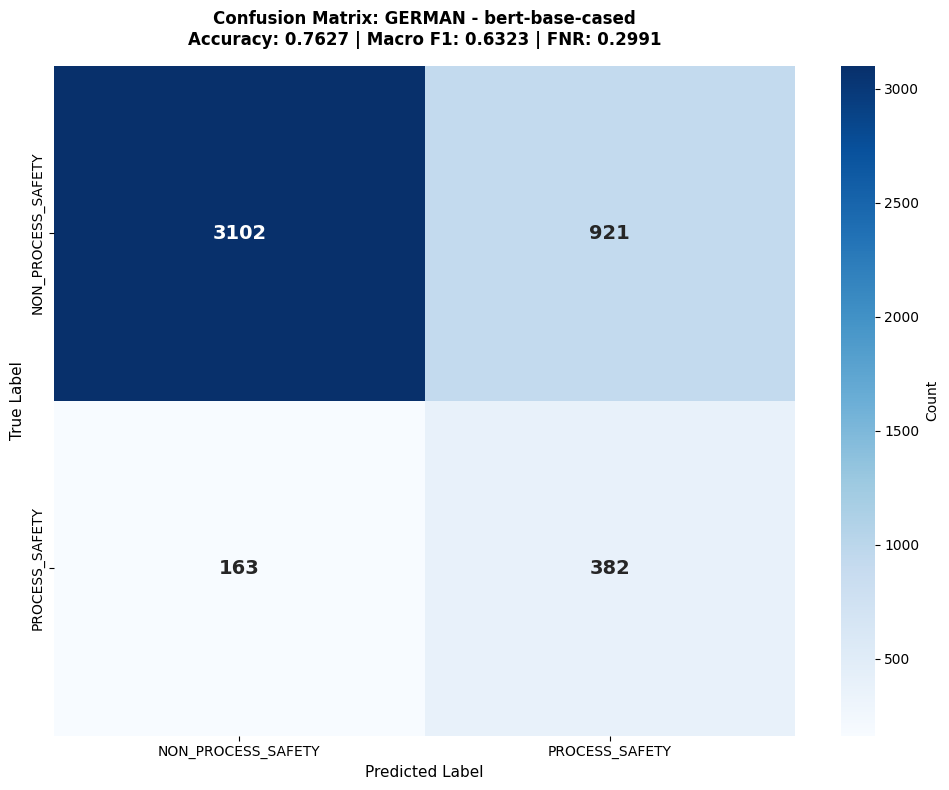

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_german_bert_base_cased.png

PIPELINE COMPLETE: GERMAN

German dataset processing complete!


In [ ]:
# =============================================================================
# English Dataset (Manual Selection) - from Iteration 0
# =============================================================================

english_manual_results = run_full_pipeline(
    df=master_df_English_manual.copy(),
    dataset_name='english_manual',
    embeddings_dir=str(EMBEDDINGS_DIR),
    results_dir=str(RESULTS_DIR)
)
all_results.append(english_manual_results)
print(f'English (manual) complete: Macro F1 = {english_manual_results["macro_f1"]:.4f}')

#### Process English Dataset (langdetect)


STEP 1: GENERATING EMBEDDINGS - UK
Dataset shape: (7032, 35)
Generating embeddings for 7032 samples...
Batch size: 16, Max length: 256
Estimated time: 14.7 minutes (440 batches)


Embedding uk: 100%|██████████| 440/440 [04:37<00:00,  1.59it/s]


Embedding generation completed in 4.6 minutes
Training set: 5625 samples
Test set: 1407 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/uk_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - UK
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/uk_bert-base-cased_embeddings.pkl
Training samples: 5625, Test samples: 1407
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 1.1 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.89      0.78      0.83       969
Process Safety       0.62      0.79      0.69       438

      accuracy                           0.78      1407
     macro avg       0.76      0.78      0.76      1407
  weighted avg       0.81      0.78   

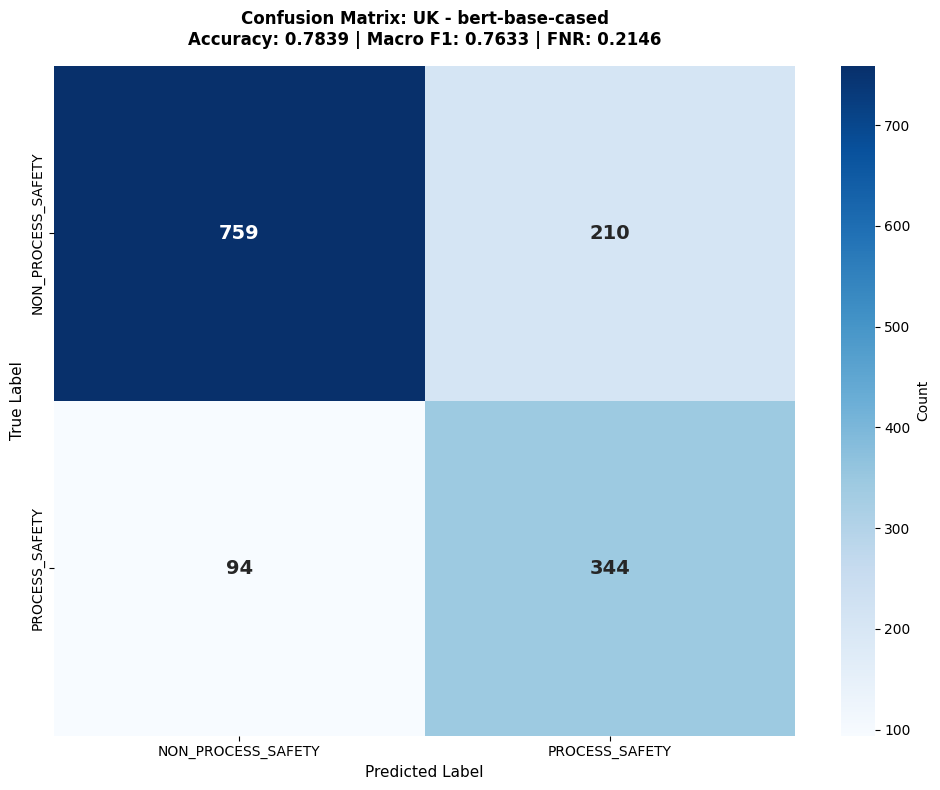

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_uk_bert_base_cased.png

PIPELINE COMPLETE: UK

UK dataset processing complete!


In [ ]:
# =============================================================================
# English Dataset (langdetect) - from Iteration 0
# =============================================================================

english_langdetect_results = run_full_pipeline(
    df=master_df_English_langdetect.copy(),
    dataset_name='english_langdetect',
    embeddings_dir=str(EMBEDDINGS_DIR),
    results_dir=str(RESULTS_DIR)
)
all_results.append(english_langdetect_results)
print(f'English (langdetect) complete: Macro F1 = {english_langdetect_results["macro_f1"]:.4f}')

#### Process English Dataset (lingua — primary)


STEP 1: GENERATING EMBEDDINGS - ENGLISH
Dataset shape: (7106, 35)
Generating embeddings for 7106 samples...
Batch size: 16, Max length: 256
Estimated time: 14.8 minutes (445 batches)


Embedding english: 100%|██████████| 445/445 [04:40<00:00,  1.59it/s]


Embedding generation completed in 4.7 minutes
Training set: 5684 samples
Test set: 1422 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/english_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - ENGLISH
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/english_bert-base-cased_embeddings.pkl
Training samples: 5684, Test samples: 1422
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 1.1 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.88      0.80      0.83       975
Process Safety       0.63      0.75      0.69       447

      accuracy                           0.78      1422
     macro avg       0.75      0.78      0.76      1422
  weighted avg       0.

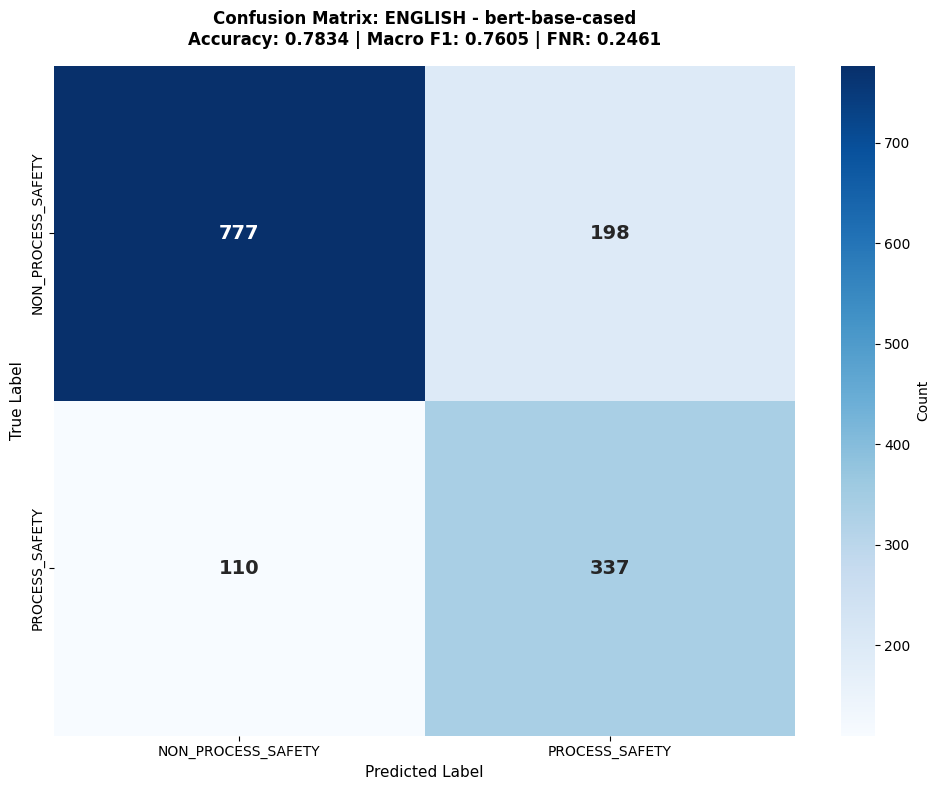

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_english_bert_base_cased.png

PIPELINE COMPLETE: ENGLISH

English dataset processing complete!


In [ ]:
# =============================================================================
# English Dataset (lingua - primary) - from Iteration 0
# =============================================================================

english_lingua_results = run_full_pipeline(
    df=master_df_English_lingua.copy(),
    dataset_name='english_lingua',
    embeddings_dir=str(EMBEDDINGS_DIR),
    results_dir=str(RESULTS_DIR)
)
all_results.append(english_lingua_results)
print(f'English (lingua) complete: Macro F1 = {english_lingua_results["macro_f1"]:.4f}')

#### Process German Dataset (lingua)

/var/folders/6j/0kkd9rzx68n1p07yf5nx299m0000gn/T/ipykernel_27456/4034020759.py:5: DtypeWarning: Columns (16,18,29) have mixed types. Specify dtype option on import or set low_memory=False.
  sweden_df = pd.read_csv(BY_COUNTRY_DIR / 'RW_ACTUALS_Sweden.csv')



STEP 1: GENERATING EMBEDDINGS - SWEDEN
Dataset shape: (20604, 35)
Generating embeddings for 20604 samples...
Batch size: 16, Max length: 256
Estimated time: 42.9 minutes (1288 batches)


Embedding sweden: 100%|██████████| 1288/1288 [06:15<00:00,  3.43it/s]


Embedding generation completed in 6.3 minutes
Training set: 16483 samples
Test set: 4121 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/sweden_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - SWEDEN
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/sweden_bert-base-cased_embeddings.pkl
Training samples: 16483, Test samples: 4121
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 5.4 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.97      0.79      0.87      3847
Process Safety       0.20      0.72      0.31       274

      accuracy                           0.78      4121
     macro avg       0.58      0.75      0.59      4121
  weighted avg       0.9

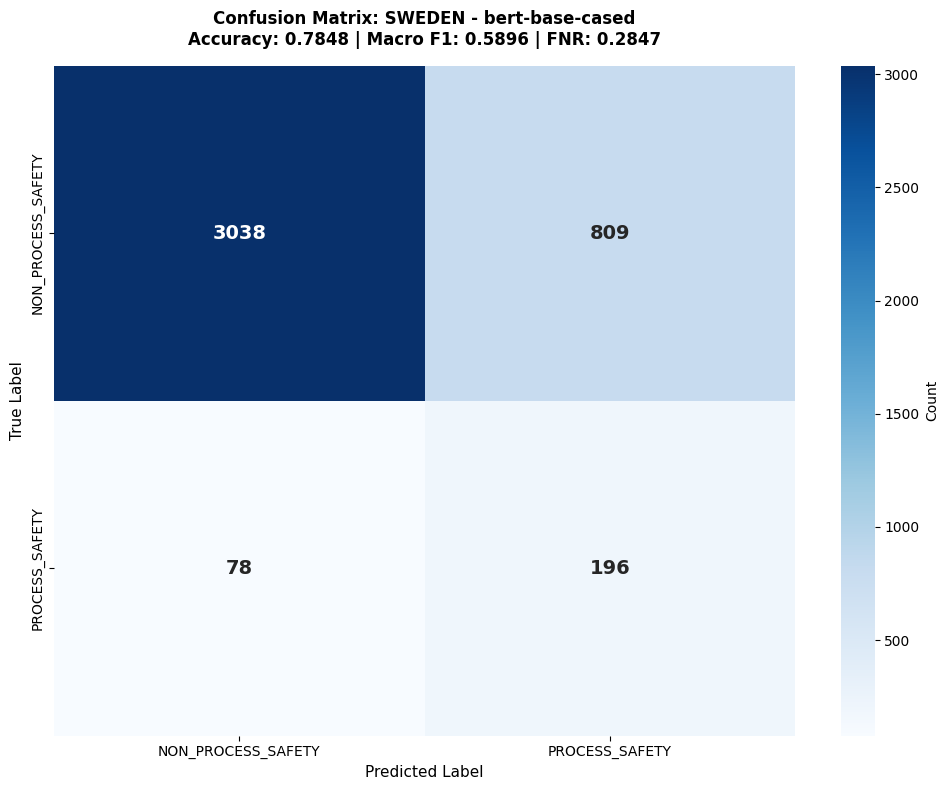

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_sweden_bert_base_cased.png

PIPELINE COMPLETE: SWEDEN

Sweden dataset processing complete!


In [ ]:
# =============================================================================
# German Dataset (lingua) - from Iteration 0
# =============================================================================

german_df = pd.read_json(PATHS['master_dataset'] / 'lingua' / 'master_df_German_lingua.json')
if 'LANGUAGE' in german_df.columns:
    german_df['LANGUAGE_CODE'] = german_df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')

german_results = run_full_pipeline(
    df=german_df,
    dataset_name='german_lingua',
    embeddings_dir=str(EMBEDDINGS_DIR),
    results_dir=str(RESULTS_DIR)
)
all_results.append(german_results)
print(f'German (lingua) complete: Macro F1 = {german_results["macro_f1"]:.4f}')

#### Process Swedish Dataset (lingua)


STEP 1: GENERATING EMBEDDINGS - NETHERLANDS
Dataset shape: (3186, 35)
Generating embeddings for 3186 samples...
Batch size: 16, Max length: 256
Estimated time: 6.7 minutes (200 batches)


Embedding netherlands: 100%|██████████| 200/200 [02:41<00:00,  1.24it/s]


Embedding generation completed in 2.7 minutes
Training set: 2548 samples
Test set: 638 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/netherlands_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - NETHERLANDS
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/netherlands_bert-base-cased_embeddings.pkl
Training samples: 2548, Test samples: 638
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 0.4 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.86      0.73      0.79       443
Process Safety       0.54      0.72      0.62       195

      accuracy                           0.73       638
     macro avg       0.70      0.73      0.70       638
  weighted av

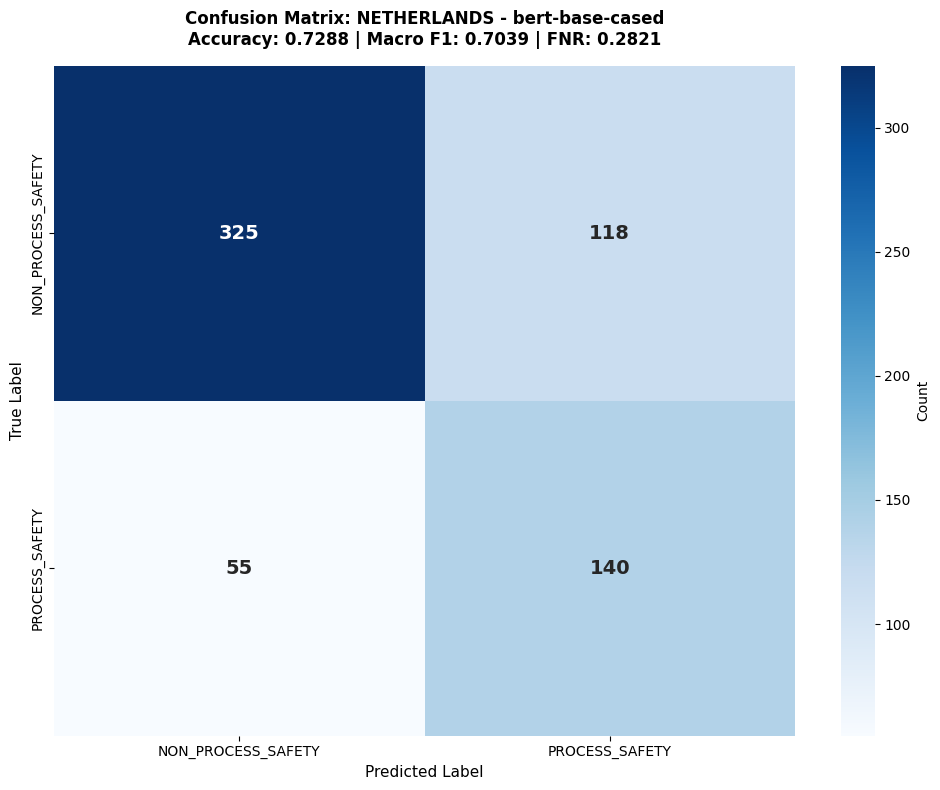

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_netherlands_bert_base_cased.png

PIPELINE COMPLETE: NETHERLANDS

Netherlands dataset processing complete!


In [ ]:
# =============================================================================
# Swedish Dataset (lingua) - from Iteration 0
# =============================================================================

swedish_df = pd.read_json(PATHS['master_dataset'] / 'lingua' / 'master_df_Swedish_lingua.json')
if 'LANGUAGE' in swedish_df.columns:
    swedish_df['LANGUAGE_CODE'] = swedish_df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')

swedish_results = run_full_pipeline(
    df=swedish_df,
    dataset_name='swedish_lingua',
    embeddings_dir=str(EMBEDDINGS_DIR),
    results_dir=str(RESULTS_DIR)
)
all_results.append(swedish_results)
print(f'Swedish (lingua) complete: Macro F1 = {swedish_results["macro_f1"]:.4f}')

#### Process Dutch Dataset (lingua)

In [ ]:
# =============================================================================
# Dutch Dataset (lingua) - from Iteration 0
# =============================================================================

dutch_df = pd.read_json(PATHS['master_dataset'] / 'lingua' / 'master_df_Dutch_lingua.json')
if 'LANGUAGE' in dutch_df.columns:
    dutch_df['LANGUAGE_CODE'] = dutch_df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')

dutch_results = run_full_pipeline(
    df=dutch_df,
    dataset_name='dutch_lingua',
    embeddings_dir=str(EMBEDDINGS_DIR),
    results_dir=str(RESULTS_DIR)
)
all_results.append(dutch_results)
print(f'Dutch (lingua) complete: Macro F1 = {dutch_results["macro_f1"]:.4f}')

No corrupted embedding file found



STEP 1: GENERATING EMBEDDINGS - MASTER_DF_1
Dataset shape: (54843, 35)
Generating embeddings for 54843 samples...
Batch size: 16, Max length: 256
Estimated time: 114.3 minutes (3428 batches)


Embedding master_df_1: 100%|██████████| 3428/3428 [33:09<00:00,  1.72it/s]


Embedding generation completed in 33.2 minutes
Training set: 43874 samples
Test set: 10969 samples
Embedding dimension: 768
Embeddings saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/master_df_1_bert-base-cased_embeddings.pkl

STEP 2: TRAINING LinearSVC (FAST) - MASTER_DF_1
Loaded embeddings from: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_1/bert-base-cased/master_df_1_bert-base-cased_embeddings.pkl
Training samples: 43874, Test samples: 10969
Training LinearSVC (class_weight='balanced', dual='auto', max_iter=10000)...
[OK] LinearSVC training completed in 14.9 seconds

Classification Report:
                precision    recall  f1-score   support

        Non-PS       0.95      0.76      0.84      9476
Process Safety       0.32      0.73      0.45      1493

      accuracy                           0.76     10969
     macro avg       0.63      0.74      0.65     10969
  wei

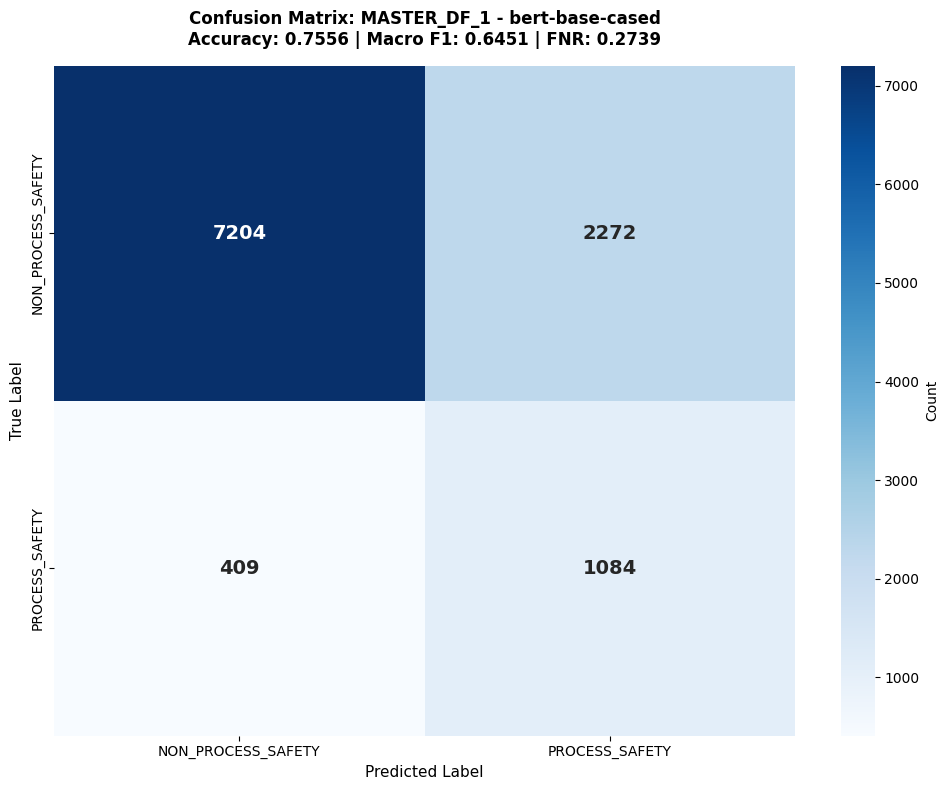

Plot saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_1/cm_master_df_1_bert_base_cased.png

PIPELINE COMPLETE: MASTER_DF_1


[OK] Master dataset processing complete!


In [ ]:
# =============================================================================
# (Optional) Full Master Dataset - all languages combined
# =============================================================================
# Uncomment to run on the full master_df (all languages, ~34K records):
# master_all_results = run_full_pipeline(
#     df=master_df.copy(),
#     dataset_name='master_all',
#     embeddings_dir=str(EMBEDDINGS_DIR),
#     results_dir=str(RESULTS_DIR)
# )
# all_results.append(master_all_results)
print('(Optional master dataset cell - uncomment to run)')

## Summary Report

In [ ]:
# ============================================================
# Generate Summary Report
# ============================================================

print(f"\n\n{'#'*100}")
print(f"{'ITERATION 1 - COMPLETE SUMMARY REPORT':^100}")
print(f"{'#'*100}\n")

# Create summary DataFrame
results_df = pd.DataFrame(all_results)

# ============================================================
# Confusion Matrix Summary
# ============================================================
print(f"\n{'CONFUSION MATRIX SUMMARY':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<15} {'TN':>10} {'FP':>10} {'FN':>10} {'TP':>10} {'Total':>12} {'Accuracy':>12} {'Macro F1':>12}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    print(f"{row['dataset'].upper():<15} {row['TN']:>10,} {row['FP']:>10,} {row['FN']:>10,} {row['TP']:>10,} {row['total']:>12,} {row['accuracy']:>12.4f} {row['macro_f1']:>12.4f}")
print(f"{'='*100}\n")

# ============================================================
# Per-Class Metrics (Classification Report Style)
# ============================================================
print(f"\n{'PER-CLASS METRICS (sklearn classification_report style)':^100}")
print(f"{'='*100}")

for _, row in results_df.iterrows():
    dataset = row['dataset'].upper()
    support_nps = row['TN'] + row['FP']  # Actual NPS samples
    support_ps = row['FN'] + row['TP']    # Actual PS samples
    total = row['total']
    
    # Weighted averages
    weighted_precision = (row['precision_nps'] * support_nps + row['precision_ps'] * support_ps) / total
    weighted_recall = (row['recall_nps'] * support_nps + row['recall_ps'] * support_ps) / total
    weighted_f1 = (row['f1_nps'] * support_nps + row['f1_ps'] * support_ps) / total
    
    # Macro averages (already have macro_f1)
    macro_precision = (row['precision_nps'] + row['precision_ps']) / 2
    macro_recall = (row['recall_nps'] + row['recall_ps']) / 2
    
    print(f"\n┌─────────────────────────────────────────────────────────────────────────────────────────────────┐")
    print(f"│ {dataset:^95} │")
    print(f"├─────────────────────────────────────────────────────────────────────────────────────────────────┤")
    print(f"│ {'Class':<20} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>12}               │")
    print(f"├─────────────────────────────────────────────────────────────────────────────────────────────────┤")
    print(f"│ {'Non-Process Safety':<20} {row['precision_nps']:>12.4f} {row['recall_nps']:>12.4f} {row['f1_nps']:>12.4f} {support_nps:>12,}               │")
    print(f"│ {'Process Safety':<20} {row['precision_ps']:>12.4f} {row['recall_ps']:>12.4f} {row['f1_ps']:>12.4f} {support_ps:>12,}               │")
    print(f"├─────────────────────────────────────────────────────────────────────────────────────────────────┤")
    print(f"│ {'Accuracy':<20} {'':>12} {'':>12} {row['accuracy']:>12.4f} {total:>12,}               │")
    print(f"│ {'Macro Avg':<20} {macro_precision:>12.4f} {macro_recall:>12.4f} {row['macro_f1']:>12.4f} {total:>12,}               │")
    print(f"│ {'Weighted Avg':<20} {weighted_precision:>12.4f} {weighted_recall:>12.4f} {weighted_f1:>12.4f} {total:>12,}               │")
    print(f"└─────────────────────────────────────────────────────────────────────────────────────────────────┘")

print(f"\n{'='*100}\n")

# ============================================================
# Detailed Metrics Summary Table
# ============================================================
print(f"\n{'DETAILED METRICS BY DATASET':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<12} {'Prec_NPS':>10} {'Rec_NPS':>10} {'F1_NPS':>10} {'Prec_PS':>10} {'Rec_PS':>10} {'F1_PS':>10} {'FPR':>10} {'FNR':>10}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    print(f"{row['dataset'].upper():<12} {row['precision_nps']:>10.4f} {row['recall_nps']:>10.4f} {row['f1_nps']:>10.4f} {row['precision_ps']:>10.4f} {row['recall_ps']:>10.4f} {row['f1_ps']:>10.4f} {row['fpr']:>10.4f} {row['fnr']:>10.4f}")
print(f"{'='*100}\n")

# ============================================================
# Error Rate Analysis
# ============================================================
print(f"\n{'ERROR RATE ANALYSIS':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<15} {'Error Rate':>12} {'FPR':>12} {'FNR':>12} {'PS Missed':>15} {'NPS Misclass.':>15}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    error_rate = 1 - row['accuracy']
    ps_missed = row['FN']  # Process Safety incidents missed (False Negatives)
    nps_misclassified = row['FP']  # Non-PS incorrectly flagged as PS (False Positives)
    print(f"{row['dataset'].upper():<15} {error_rate:>12.4f} {row['fpr']:>12.4f} {row['fnr']:>12.4f} {ps_missed:>15,} {nps_misclassified:>15,}")
print(f"{'='*100}\n")

# ============================================================
# Class Imbalance Analysis
# ============================================================
print(f"\n{'CLASS IMBALANCE ANALYSIS':^100}")
print(f"{'='*100}")
print(f"{'Dataset':<15} {'Total':>10} {'NPS Count':>12} {'PS Count':>12} {'NPS %':>10} {'PS %':>10} {'Imbalance Ratio':>18}")
print(f"{'-'*100}")
for _, row in results_df.iterrows():
    nps_count = row['TN'] + row['FP']  # Actual NPS
    ps_count = row['FN'] + row['TP']    # Actual PS
    nps_pct = (nps_count / row['total']) * 100
    ps_pct = (ps_count / row['total']) * 100
    imbalance_ratio = max(nps_count, ps_count) / min(nps_count, ps_count) if min(nps_count, ps_count) > 0 else float('inf')
    print(f"{row['dataset'].upper():<15} {row['total']:>10,} {nps_count:>12,} {ps_count:>12,} {nps_pct:>9.1f}% {ps_pct:>9.1f}% {imbalance_ratio:>17.2f}:1")
print(f"{'='*100}\n")

# ============================================================
# Key Observations
# ============================================================
print(f"\n{'KEY OBSERVATIONS':^100}")
print(f"{'='*100}")
print(f"\n  Performance Metrics:")
print(f"  • Total datasets processed: {len(results_df)}")
print(f"  • Best Macro F1: {results_df['macro_f1'].max():.4f} ({results_df.loc[results_df['macro_f1'].idxmax(), 'dataset'].upper()})")
print(f"  • Worst Macro F1: {results_df['macro_f1'].min():.4f} ({results_df.loc[results_df['macro_f1'].idxmin(), 'dataset'].upper()})")
print(f"  • Average Macro F1: {results_df['macro_f1'].mean():.4f}")
print(f"  • Average Accuracy: {results_df['accuracy'].mean():.4f}")

print(f"\n  Error Rates (Critical for Safety):")
print(f"  • Lowest FNR (best - fewest PS incidents missed): {results_df['fnr'].min():.4f} ({results_df.loc[results_df['fnr'].idxmin(), 'dataset'].upper()})")
print(f"  • Highest FNR (worst - most PS incidents missed): {results_df['fnr'].max():.4f} ({results_df.loc[results_df['fnr'].idxmax(), 'dataset'].upper()})")
print(f"  • Average FNR: {results_df['fnr'].mean():.4f}")
print(f"  • Average FPR: {results_df['fpr'].mean():.4f}")

print(f"\n  Precision-Recall Trade-off:")
best_ps_precision_idx = results_df['precision_ps'].idxmax()
best_ps_recall_idx = results_df['recall_ps'].idxmax()
print(f"  • Best PS Precision: {results_df['precision_ps'].max():.4f} ({results_df.loc[best_ps_precision_idx, 'dataset'].upper()})")
print(f"  • Best PS Recall: {results_df['recall_ps'].max():.4f} ({results_df.loc[best_ps_recall_idx, 'dataset'].upper()})")
print(f"  • Average PS Precision: {results_df['precision_ps'].mean():.4f}")
print(f"  • Average PS Recall: {results_df['recall_ps'].mean():.4f}")
print(f"{'='*100}\n")

# ============================================================
# Comparison with Baseline
# ============================================================
print(f"\n{'COMPARISON WITH ITERATION 0 BASELINE':^100}")
print(f"{'='*100}")
print(f"Iteration 0 Baseline (bert-base-uncased, English only): Macro F1 = 0.766")
print(f"RQ1 Target: Macro F1 ≥ 0.81 (+5 percentage points improvement)\n")
for _, row in results_df.iterrows():
    improvement = row['macro_f1'] - 0.766
    status = "[OK] TARGET MET" if row['macro_f1'] >= 0.81 else "[X] Below Target"
    print(f"  {row['dataset'].upper():<15}: Macro F1 = {row['macro_f1']:.4f} (Δ = {improvement:+.4f}) {status}")

# Summary statistics
met_target = (results_df['macro_f1'] >= 0.81).sum()
print(f"\n  Summary: {met_target}/{len(results_df)} datasets met the RQ1 target (≥0.81 Macro F1)")
print(f"{'='*100}\n")

# ============================================================
# Save Results
# ============================================================
summary_file = os.path.join(RESULTS_DIR, 'iteration_1_summary.csv')
results_df.to_csv(summary_file, index=False)
print(f"Summary saved to: {summary_file}")

# ============================================================
# Section 9: Markdown Tables for LaTeX/Thesis
# ============================================================
print(f"\n\n{'MARKDOWN TABLES (for LaTeX/Thesis)':^100}")
print(f"{'='*100}\n")

print("Table 1: Confusion Matrix Summary")
display_cols = ['dataset', 'TN', 'FP', 'FN', 'TP', 'accuracy', 'macro_f1']
print(results_df[display_cols].to_markdown(index=False, floatfmt='.4f'))

print("\n\nTable 2: Per-Class Precision, Recall, F1-Score")
class_metrics_cols = ['dataset', 'precision_nps', 'recall_nps', 'f1_nps', 'precision_ps', 'recall_ps', 'f1_ps']
print(results_df[class_metrics_cols].to_markdown(index=False, floatfmt='.4f'))

print("\n\nTable 3: Error Rates")
error_cols = ['dataset', 'fpr', 'fnr']
results_df['error_rate'] = 1 - results_df['accuracy']
error_display = results_df[['dataset', 'error_rate', 'fpr', 'fnr']].copy()
print(error_display.to_markdown(index=False, floatfmt='.4f'))

print(f"\n\n{'='*100}")
print(f"{'ITERATION 1 PIPELINE COMPLETE':^100}")
print(f"{'='*100}")

# =============================================================================
# Save iteration_1_summary.json (consistent with Iteration 0 format)
# =============================================================================
import json as _json

_results_df = pd.DataFrame(all_results)
_RQ1_TARGET = 0.85

_summary = {
    'iteration': 1,
    'model': 'bert-base-cased + LinearSVC',
    'best_dataset': str(_results_df.loc[_results_df['macro_f1'].idxmax(), 'dataset']),
    'datasets': {},
    'gap_analysis': {}
}

for _, row in _results_df.iterrows():
    name = row['dataset']
    _summary['datasets'][name] = {
        'total_samples': int(row['total']),
        'results': {
            'accuracy':     round(float(row['accuracy']), 4),
            'macro_f1':     round(float(row['macro_f1']), 4),
            'precision_ps': round(float(row['precision_ps']), 4),
            'recall_ps':    round(float(row['recall_ps']), 4),
            'f1_ps':        round(float(row['f1_ps']), 4),
        },
        'confusion_matrix': {
            'tn': int(row['TN']), 'fp': int(row['FP']),
            'fn': int(row['FN']), 'tp': int(row['TP']),
        }
    }
    _summary['gap_analysis'][name] = {
        'current_macro_f1': round(float(row['macro_f1']), 4),
        'rq1_target': _RQ1_TARGET,
        'gap': round(float(_RQ1_TARGET - row['macro_f1']), 4)
    }

_out_path = PATHS['results'] / 'iteration_1_summary.json'
with open(_out_path, 'w', encoding='utf-8') as _f:
    _json.dump(_summary, _f, indent=2, ensure_ascii=False)
print(f'[OK] Saved: {_out_path}')
print(f'Best dataset: {_summary["best_dataset"]} (Macro F1 = {_results_df["macro_f1"].max():.4f})')



####################################################################################################
                               ITERATION 1 - COMPLETE SUMMARY REPORT                                
####################################################################################################


                                      CONFUSION MATRIX SUMMARY                                      
Dataset                 TN         FP         FN         TP        Total     Accuracy     Macro F1
----------------------------------------------------------------------------------------------------
GERMAN               3,102        921        163        382        4,568       0.7627       0.6323
UK                     759        210         94        344        1,407       0.7839       0.7633
ENGLISH                777        198        110        337        1,422       0.7834       0.7605
SWEDEN               3,038        809         78        196        4,121       0.7848       0.5